# 08 · Evaluating the retrieval system

The previous notebooks built a system with several interchangeable parts, a chunk strategy, an
embedding model, a retrieval mode and a reranker, and two ways of answering. This notebook explains
how those choices were evaluated and reports which configuration was selected.

The evaluation code is `ocular/rag/eval_rag.py` and the question set is produced by
`ocular/rag/questions.py`. The sweeps were run by `experiments/run_rag_eval.py` (the retrieval
configurations) and `experiments/run_phaseb.py` (basic against agentic), which wrote their results
to the two CSV files this notebook reads.

## Reference-free evaluation

The system is scored without any hand-written answers or relevance labels, using a language model
as the judge. Three metrics are computed, the standard reference-free set.

**Faithfulness** asks whether every claim in the answer is supported by the retrieved passages,
which is the check for invented content and matters most for a clinical tool. **Answer relevance**
asks whether the answer addresses the question. **Context precision** asks what fraction of the
retrieved passages are relevant to the question, and it stands in for the labelled retrieval
metrics that a manual gold set would provide.

This approach avoids the labour of building a gold set, but two honest limitations follow. The
judge is the sole authority, so its biases become the reported numbers, and a faithful answer built
on wrongly retrieved passages can still be factually wrong, because faithfulness measures grounding
rather than correctness.

## The synthetic question set

The evaluation still needs questions, which are generated from the corpus itself. A passage is
sampled from an article and the language model is asked to write a realistic clinical question that
the passage answers. Two safeguards protect the quality of the set. The model is instructed to
paraphrase rather than copy the passage, so the questions are not trivially retrievable by matching
words, and it first judges whether the passage carries clinical substance, skipping passages that
are protocol, statistics or disclosures. Fifty questions were produced in this way, each drawn from
a different article.

In [1]:
from ocular.rag import questions

qs = questions.load_questions()
print(f"{len(qs)} evaluation questions\n")
for q in qs[:3]:
    print("-", q.question)

50 evaluation questions

- What is the relationship between axial length and spherical equivalent in the context of refractive development?
- What proportion of chronic central serous chorioretinopathy patients present with bilateral subretinal fluid on baseline optical coherence tomography?
- What is a major contributor to the carbon footprint associated with intravitreal injections?


## Phase A, choosing the retrieval configuration

The first sweep varied the four retrieval choices and scored each configuration on the question
set. A first observation shapes everything that follows. Faithfulness and answer relevance are
almost always at their maximum, so the grounding is robust but these two metrics do not
distinguish the configurations. Context precision is therefore the metric that carries the
signal.

In [2]:
import pandas as pd

from ocular import config

RESULTS = config.ROOT / "experiments" / "results"
a = pd.read_csv(RESULTS / "rag_eval.csv")
a[["faithfulness", "answer_relevance", "context_precision"]].agg(["mean", "min", "max"]).round(3)

,faithfulness,answer_relevance,context_precision
mean,1.0,0.999,0.677
min,1.0,0.990,0.506
max,1.0,1.000,0.798


### The reranker is the most influential choice

Comparing the two rerankers on the same configuration, a small ModernBERT reranker raised context
precision by roughly six points over the ms-marco baseline, consistently across every embedding
model. This gain is larger than the effect of any other single choice, which is why the reranker
was treated as the decisive component. A far heavier reranker was also tried and discarded, because
it improved the score by only one point while making each query about twenty seconds slower.

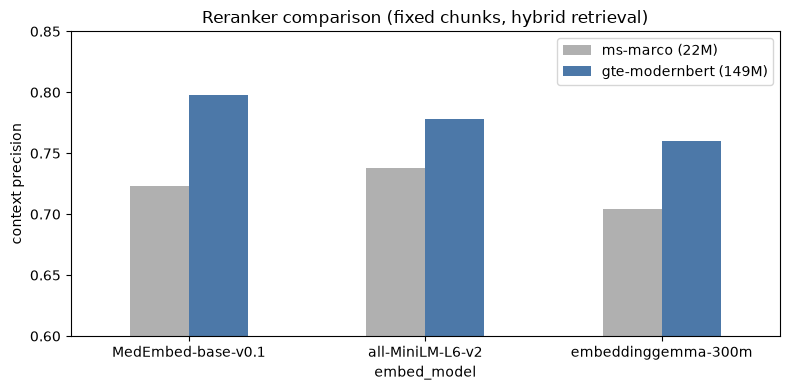

In [3]:
import matplotlib.pyplot as plt

r = a[(a["chunk_strategy"] == "fixed") & (a["mode"] == "hybrid") & (a["rerank"] != "none")].copy()
r["reranker"] = r["rerank"].map({
    "ms-marco-MiniLM-L-6-v2": "ms-marco (22M)",
    "gte-reranker-modernbert-base": "gte-modernbert (149M)",
})
piv = r.pivot_table(index="embed_model", columns="reranker", values="context_precision")
piv[["ms-marco (22M)", "gte-modernbert (149M)"]].plot.bar(figsize=(8, 4), color=["#B0B0B0", "#4C78A8"], rot=0)
plt.ylabel("context precision")
plt.title("Reranker comparison (fixed chunks, hybrid retrieval)")
plt.ylim(0.6, 0.85)
plt.legend(title="")
plt.tight_layout()
plt.show()

### Chunk strategy, retrieval mode and embedding model

The remaining choices matter less but are consistent. Among the chunk strategies the fixed one is
best and the semantic one is worst, which is the reverse of the intuition that a topic-aware split
should help. Among the retrieval modes the hybrid fusion is best, and the vector mode alone is
worst, since the specific factual questions reward exact term overlap. Among the embedding models
the differences are small once the reranker is applied, and the biomedical model ends up slightly
ahead.

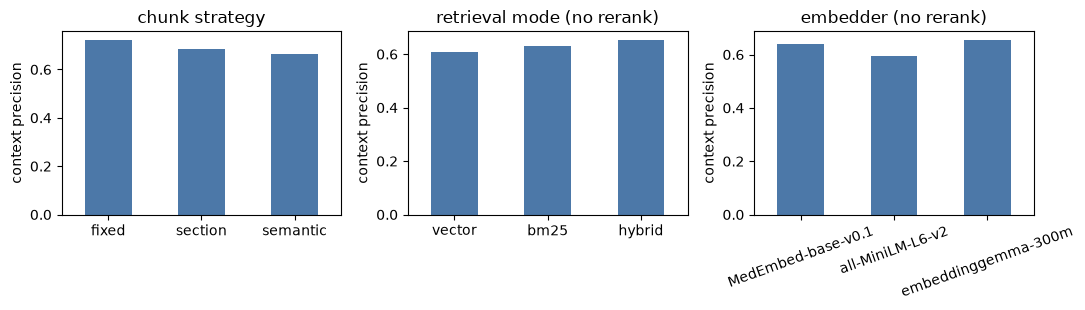

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2))

strat = a[(a["mode"] == "hybrid") & (a["rerank"] == "ms-marco-MiniLM-L-6-v2")]
strat.groupby("chunk_strategy")["context_precision"].mean().reindex(["fixed", "section", "semantic"]).plot.bar(
    ax=axes[0], color="#4C78A8", rot=0, title="chunk strategy")

mode = a[a["rerank"] == "none"]
mode.groupby("mode")["context_precision"].mean().reindex(["vector", "bm25", "hybrid"]).plot.bar(
    ax=axes[1], color="#4C78A8", rot=0, title="retrieval mode (no rerank)")

emb = a[a["rerank"] == "none"]
emb.groupby("embed_model")["context_precision"].mean().plot.bar(
    ax=axes[2], color="#4C78A8", rot=20, title="embedder (no rerank)")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("context precision")
plt.tight_layout()
plt.show()

### The selected configuration

Putting the strongest option for each choice together gives fixed chunks, hybrid retrieval, the
gte-modernbert reranker and the biomedical embedding model, which reaches a context precision of
about 0.80. This is the configuration carried into the second phase and into the deployed system.

## Phase B, basic against agentic answering

With the retrieval fixed, the second sweep compared two ways of answering. The **basic** pipeline
retrieves once and then generates. The **agentic** pipeline is a LangGraph agent that decides for
itself when to search, may reformulate the question and search again, and then answers. Both were
run on the selected strong configuration and, to test a hypothesis, on a deliberately weak one.

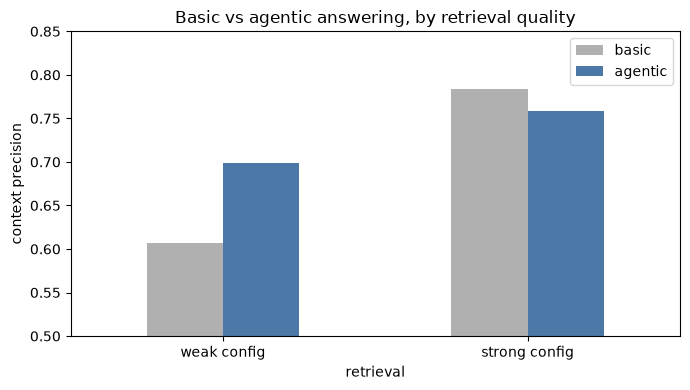

pipeline,basic,agentic
retrieval,,
weak config,0.607,0.698
strong config,0.784,0.758


In [5]:
b = pd.read_csv(RESULTS / "rag_eval_phaseb.csv")
b["retrieval"] = b["rerank"].apply(lambda x: "strong config" if x != "none" else "weak config")
piv = b.pivot_table(index="retrieval", columns="pipeline", values="context_precision")
piv = piv.reindex(["weak config", "strong config"])[["basic", "agentic"]]
piv.plot.bar(figsize=(7, 4), color=["#B0B0B0", "#4C78A8"], rot=0)
plt.ylabel("context precision")
plt.title("Basic vs agentic answering, by retrieval quality")
plt.ylim(0.5, 0.85)
plt.legend(title="")
plt.tight_layout()
plt.show()
piv.round(3)

The result is clear and instructive. On the strong retrieval the agent slightly hurts, because
its additional searches gather extra passages that dilute the precision, and it is also slower. On
the weak retrieval the agent helps substantially, because its ability to reformulate and search
again recovers much of what the poor first retrieval missed.

The value of the agent is therefore inversely related to the quality of the retrieval. The
practical conclusion is to invest in retrieval first, and to treat the agent as a remedy for weak
retrieval rather than an improvement over strong retrieval. Since the selected configuration
retrieves well, the deployed answerer uses the basic pipeline.

## What was run

The question set was generated once with

    python scripts/build_questions.py --n 50

The retrieval sweep was run in stages, comparing embedders, then rerankers, then strategies,

    python experiments/run_rag_eval.py --limit 50
    python experiments/run_rag_eval.py --rerank off --modes vector bm25 hybrid
    python experiments/run_rag_eval.py --strategies fixed semantic --modes hybrid --rerank on
    python experiments/run_rag_eval.py --strategies fixed --modes hybrid --reranker Alibaba-NLP/gte-reranker-modernbert-base

and the two answering pipelines were compared with

    python experiments/run_phaseb.py
    python experiments/run_phaseb.py --index fixed__all-MiniLM-L6-v2 --mode vector --rerank off

Every run appends to its results CSV and skips configurations already recorded, so the sweeps could
be built up gradually rather than in one long execution.

## Summary

- The system was evaluated **without a gold set**, using a language model to score faithfulness,
  answer relevance and context precision.
- Faithfulness and answer relevance are saturated, so **context precision** carried the signal.
- The **reranker** was the most influential retrieval choice, and a small ModernBERT reranker gave
  the best balance of quality and speed.
- The selected configuration is **fixed chunks, hybrid retrieval, the gte-modernbert reranker and
  the biomedical embedder**.
- **Basic answering was chosen** over the agent, whose value appears only when retrieval is weak.

The retrieval and answering system is now fixed. The remaining work is the application that puts it
in front of a clinician alongside the image classifier.